In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed/listings_final.csv")

# Fill source column if absent (tayara rows have no 'source' column)
if 'source' not in df.columns:
    df['source'] = 'tayara'
else:
    df['source'] = df['source'].fillna('tayara')

FEATURES = ['superficie', 'chambres', 'salles_de_bains', 'location', 'source']
TARGET = 'log_price'

# Fill missing salles_de_bains with median
df['salles_de_bains'] = df['salles_de_bains'].fillna(df['salles_de_bains'].median())

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nSource distribution:\n{df['source'].value_counts()}")
print(f"\nMedian price by source:")
print(df.groupby('source')['price'].median().apply(lambda x: f"{x:,.0f} DT"))


Train: (3184, 5), Test: (796, 5)

Source distribution:
source
mubawab    3605
tayara      375
Name: count, dtype: int64

Median price by source:
source
mubawab    360,000 DT
tayara     260,000 DT
Name: price, dtype: object


In [17]:
categorical = ['location', 'source']
numerical = ['superficie', 'chambres', 'salles_de_bains']

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numerical),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05,
                            max_depth=5, subsample=0.8, random_state=42)
}


In [18]:
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred_log = pipe.predict(X_test)
    
    # Convert back from log scale to real DT
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'pipeline': pipe}
    print(f"{name}: MAE = {mae:,.0f} DT | RMSE = {rmse:,.0f} DT")

Linear Regression: MAE = 118,118 DT | RMSE = 296,291 DT
Random Forest: MAE = 101,859 DT | RMSE = 211,193 DT
XGBoost: MAE = 94,444 DT | RMSE = 206,436 DT


In [19]:
# Pick best model by MAE
best_name = min(results, key=lambda k: results[k]['MAE'])
best_pipeline = results[best_name]['pipeline']
print(f"Best model: {best_name}")

joblib.dump(best_pipeline, '../models/model.pkl')
print("Model saved to models/model.pkl")

Best model: XGBoost
Model saved to models/model.pkl


In [20]:
import warnings
warnings.filterwarnings('ignore')

sample = pd.DataFrame([{
    'superficie': 100,
    'chambres': 2,
    'salles_de_bains': 1,
    'location': 'Tunis',
    'source': 'mubawab'
}])

log_pred = best_pipeline.predict(sample)[0]
price_pred = np.expm1(log_pred)
print(f"Predicted price for 100m² S+2 in Tunis (mubawab): {price_pred:,.0f} DT")

sample_tayara = sample.copy()
sample_tayara['source'] = 'tayara'
log_pred2 = best_pipeline.predict(sample_tayara)[0]
price_pred2 = np.expm1(log_pred2)
print(f"Predicted price for 100m² S+2 in Tunis (tayara):  {price_pred2:,.0f} DT")


Predicted price for 100m² S+2 in Tunis (mubawab): 219,689 DT
Predicted price for 100m² S+2 in Tunis (tayara):  283,720 DT


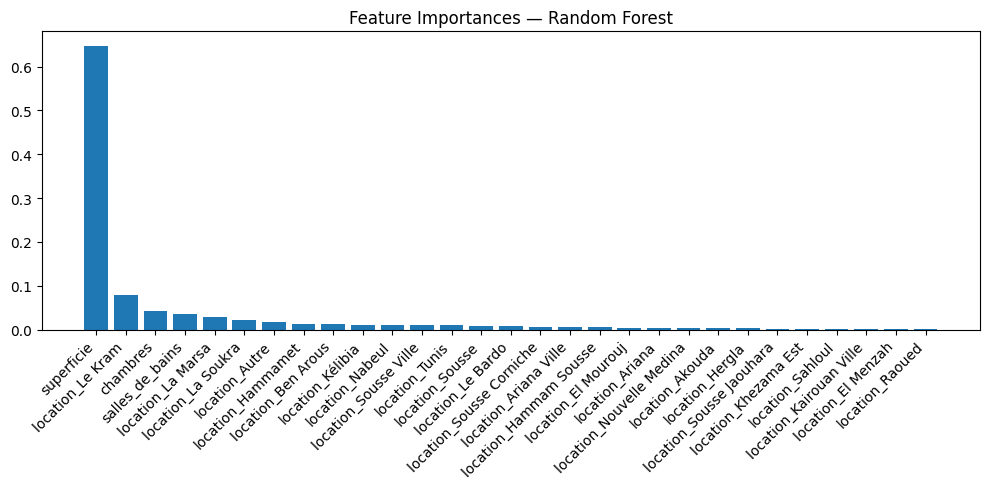

Saved feature importance chart


In [6]:
import matplotlib.pyplot as plt
import numpy as np

rf_model = results["Random Forest"]["pipeline"].named_steps["model"]
ohe_features = list(
    results["Random Forest"]["pipeline"]
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(["location"])
)
feature_names = ["superficie", "chambres", "salles_de_bains"] + ohe_features
importances = rf_model.feature_importances_

# Use actual number of features instead of hardcoded 10
n = len(feature_names)
indices = np.argsort(importances)[::-1][:n]

plt.figure(figsize=(10, 5))
plt.bar(range(n), importances[indices])
plt.xticks(range(n), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title("Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("../models/feature_importance.png", dpi=150)
plt.show()
print("Saved feature importance chart")

=== Shape ===
(1575, 11)

=== Price stats ===
count        1,575
mean       399,972
std        248,835
min         45,000
25%        240,000
50%        335,000
75%        475,000
max      1,850,000
Name: price, dtype: object

=== Superficie stats ===
count    1,575.0
mean       120.5
std         60.0
min         30.0
25%         80.0
50%        111.0
75%        140.0
max        600.0
Name: superficie, dtype: object

=== Listing count per location ===
location
La Marsa           209
Tunis              170
La Soukra          167
Le Kram            133
Autre              122
Nabeul             117
Ariana Ville        87
Sousse              80
Hammamet            75
Ariana              55
Ben Arous           40
Hammam Sousse       35
Sousse Ville        30
Kélibia             28
Sousse Jaouhara     23
Nouvelle Medina     23
Hergla              23
Sahloul             22
Khezama Est         21
Le Bardo            21
Kairouan Ville      20
El Menzah           18
Raoued              18
Akouda 

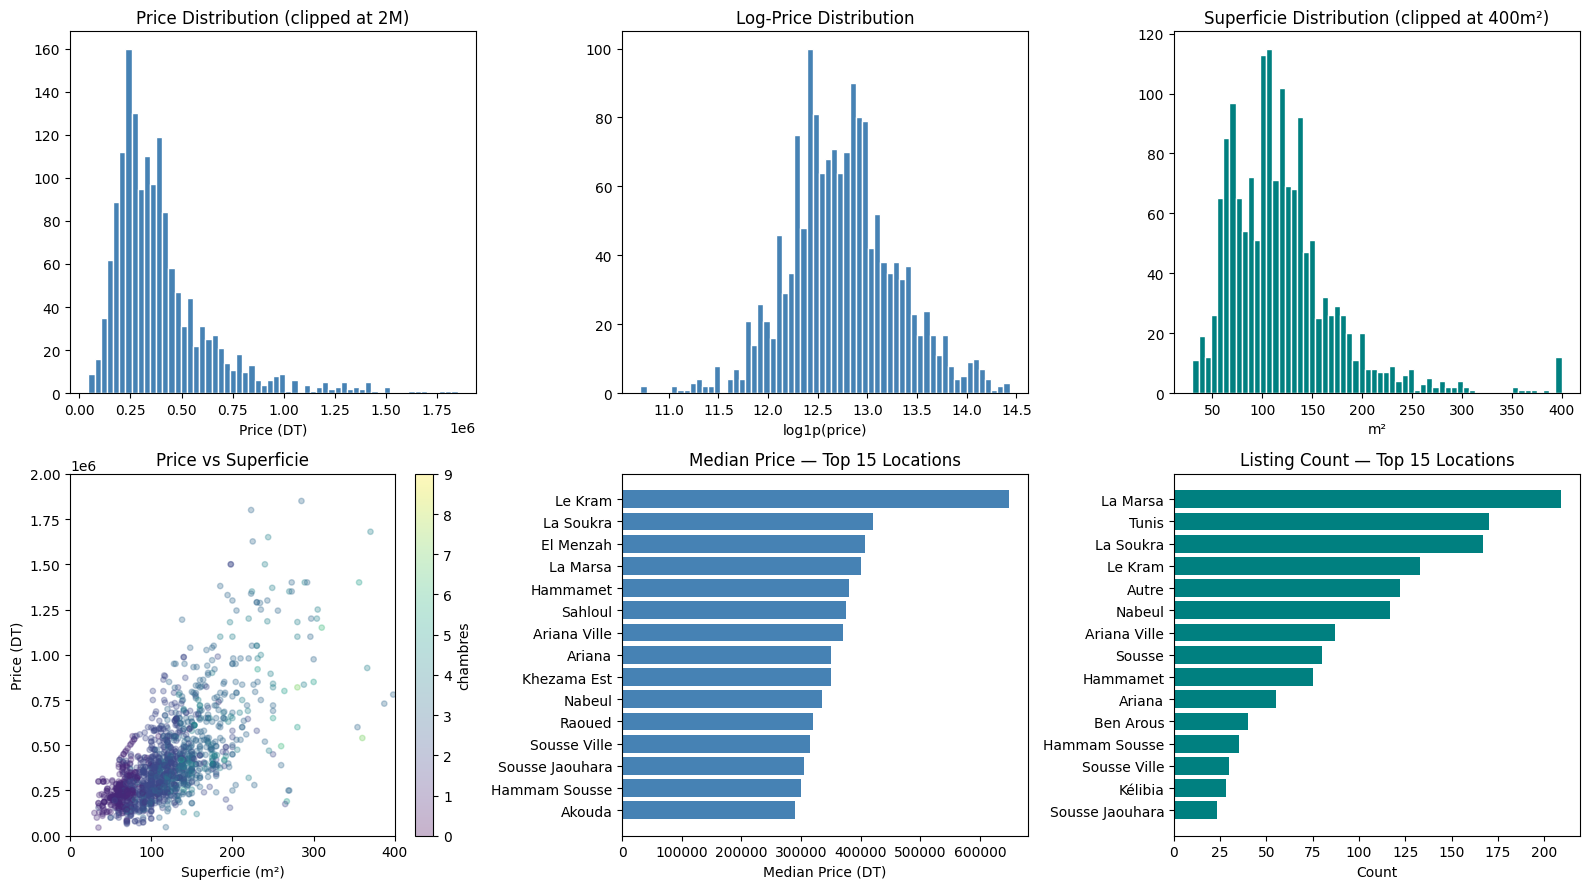

Chart saved → models/data_diagnosis.png


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/listings_final.csv")

print("=== Shape ===")
print(df.shape)

print("\n=== Price stats ===")
print(df['price'].describe().apply(lambda x: f"{x:,.0f}"))

print("\n=== Superficie stats ===")
print(df['superficie'].describe().apply(lambda x: f"{x:,.1f}"))

print("\n=== Listing count per location ===")
print(df['location'].value_counts().to_string())

print("\n=== Median price per location (top 15) ===")
med = df.groupby('location')['price'].median().sort_values(ascending=False)
print(med.head(15).apply(lambda x: f"{x:,.0f} DT").to_string())

print("\n=== Missing values ===")
print(df[['price','superficie','chambres','salles_de_bains','location']].isnull().sum())

# --- Plots ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Price histogram
axes[0,0].hist(df['price'].clip(upper=2_000_000), bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title("Price Distribution (clipped at 2M)")
axes[0,0].set_xlabel("Price (DT)")

# 2. Log-price histogram
axes[0,1].hist(df['log_price'], bins=60, color='steelblue', edgecolor='white')
axes[0,1].set_title("Log-Price Distribution")
axes[0,1].set_xlabel("log1p(price)")

# 3. Superficie histogram
axes[0,2].hist(df['superficie'].clip(upper=400), bins=60, color='teal', edgecolor='white')
axes[0,2].set_title("Superficie Distribution (clipped at 400m²)")
axes[0,2].set_xlabel("m²")

# 4. Price vs superficie scatter (coloured by chambres)
sc = axes[1,0].scatter(df['superficie'], df['price'], c=df['chambres'],
                        cmap='viridis', alpha=0.3, s=15)
axes[1,0].set_xlim(0, 400); axes[1,0].set_ylim(0, 2_000_000)
axes[1,0].set_title("Price vs Superficie")
axes[1,0].set_xlabel("Superficie (m²)"); axes[1,0].set_ylabel("Price (DT)")
plt.colorbar(sc, ax=axes[1,0], label='chambres')

# 5. Median price by top-15 locations
top15 = med.head(15)
axes[1,1].barh(top15.index[::-1], top15.values[::-1], color='steelblue')
axes[1,1].set_title("Median Price — Top 15 Locations")
axes[1,1].set_xlabel("Median Price (DT)")

# 6. Listing count per location (top 15)
top15_count = df['location'].value_counts().head(15)
axes[1,2].barh(top15_count.index[::-1], top15_count.values[::-1], color='teal')
axes[1,2].set_title("Listing Count — Top 15 Locations")
axes[1,2].set_xlabel("Count")

plt.tight_layout()
plt.savefig("../models/data_diagnosis.png", dpi=150)
plt.show()
print("Chart saved → models/data_diagnosis.png")


Le Kram total listings: 133

Price distribution:
count          133
mean       705,138
std        288,335
min        260,778
25%        532,700
50%        648,000
75%        795,000
max      1,800,000
Name: price, dtype: object

By source:
        count      min      50%        max
source                                    
mubawab   133  260,778  648,000  1,800,000

Sample Le Kram listings (sorted by price desc):
          price  superficie  chambres   source
570   1800000.0       223.0       3.0  mubawab
1471  1650000.0       244.0       4.0  mubawab
805   1626500.0       225.0       3.0  mubawab
1135  1500000.0       240.0       4.0  mubawab
851   1450000.0       500.0       4.0  mubawab
1170  1400000.0       292.0       3.0  mubawab
1257  1370000.0       249.0       4.0  mubawab
903   1350000.0       224.0       4.0  mubawab
1309  1338000.0       223.0       3.0  mubawab
766   1244500.0       205.0       3.0  mubawab
1321  1185000.0       243.0       4.0  mubawab
569   1039000.0   

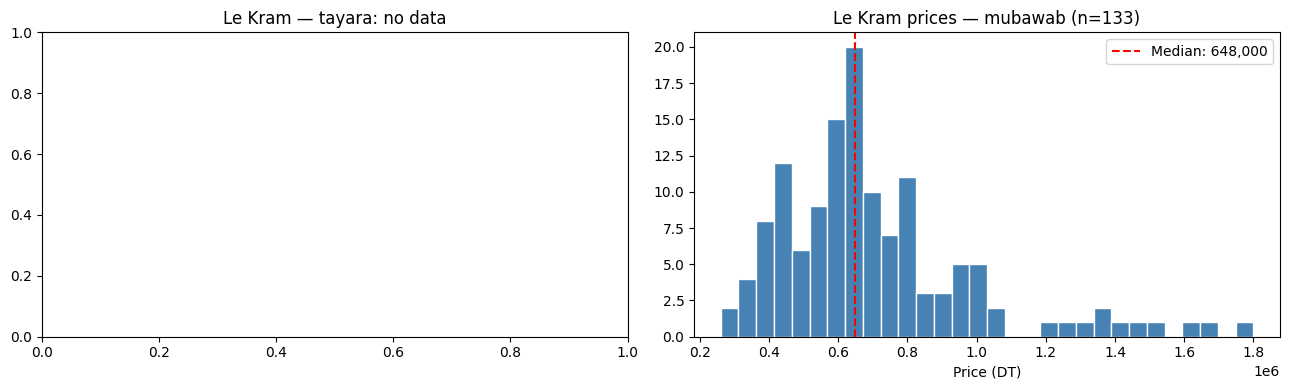

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/processed/listings_final.csv")

kram = df[df['location'] == 'Le Kram']
print(f"Le Kram total listings: {len(kram)}")
print(f"\nPrice distribution:")
print(kram['price'].describe().apply(lambda x: f"{x:,.0f}"))
print(f"\nBy source:")
print(kram.groupby('source')['price'].describe()[['count','min','50%','max']].applymap(lambda x: f"{x:,.0f}"))

print(f"\nSample Le Kram listings (sorted by price desc):")
print(kram[['price','superficie','chambres','source']].sort_values('price', ascending=False).head(20).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, src in zip(axes, ['tayara', 'mubawab']):
    subset = kram[kram['source'] == src]['price']
    if len(subset):
        ax.hist(subset, bins=30, color='steelblue', edgecolor='white')
        ax.axvline(subset.median(), color='red', linestyle='--', label=f'Median: {subset.median():,.0f}')
        ax.set_title(f"Le Kram prices — {src} (n={len(subset)})")
        ax.set_xlabel("Price (DT)")
        ax.legend()
    else:
        ax.set_title(f"Le Kram — {src}: no data")

plt.tight_layout()
plt.show()
